# RQ1 Notebook

In [ ]:
"""
RQ1 - Multi-Parent Reuse with 2-Hop Family Resolution

Supervisor-requested fixes:
  1. Report in-degree == 2, 3, 4, 5 individually (not just >=2,3,5,10)
  2. Report average in-degree across all multi-parent nodes
  3. For in-degree == 3, 4, 5: report TOP 10 family merge combos
     and explicitly split same-family (inbreeding) vs cross-family (outbreeding) ratios
  4. Global average in-degree reported in summary

Outputs:
  - rq1_multi_parent_nodes.csv
  - rq1_family_pairs.csv
  - rq1_indegree_breakdown.csv
  - rq1_top_combos_by_degree.csv   ← NEW: top 10 combos per degree, inbreed/outbreed labelled
  - rq1_summary.txt
"""

import pandas as pd
import networkx as nx
import re
from itertools import combinations
from collections import Counter
import statistics

EDGES_FILE = "edges.csv"
NODES_FILE = "all_text_generation_models.csv"

print("Loading data...")
edges = pd.read_csv(EDGES_FILE)
nodes = pd.read_csv(NODES_FILE)

if "Id" in nodes.columns and "model_id" not in nodes.columns:
    nodes = nodes.rename(columns={"Id": "model_id"})

nodes["downloads"] = pd.to_numeric(nodes["downloads"], errors="coerce").fillna(0)

G = nx.from_pandas_edgelist(
    edges, source="Source", target="Target",
    edge_attr=["Transformation", "Confidence"],
    create_using=nx.DiGraph()
)

in_deg  = dict(G.in_degree())
out_deg = dict(G.out_degree())

# Pre compute maps for quick access during multi-parent analysis
downloads_map   = nodes.set_index("model_id")["downloads"].to_dict()
creator_map     = nodes.set_index("model_id")["creator"].to_dict()
tags_map        = nodes.set_index("model_id")["tags"].to_dict()
edge_transforms = edges.groupby("Target")["Transformation"].apply(list).to_dict()

# Family patterns for heuristic matching (for 2-hop resolution)
FAMILY_PATTERNS = [
    ("LLaMA",    [r"llama"]),
    ("Qwen",     [r"\bqwen\b"]),
    ("Mistral",  [r"mistral"]),
    ("GPT",      [r"\bgpt\b", r"openai"]),
    ("DeepSeek", [r"deepseek"]),
    ("Gemma",    [r"gemma"]),
    ("Falcon",   [r"falcon"]),
    ("BLOOM",    [r"bloom"]),
    ("Phi",      [r"\bphi\b"]),
    ("OPT",      [r"\bopt\b"]),
    ("T5",       [r"\bt5\b"]),
    ("Yi",       [r"\byi\b"]),
    ("Nemotron", [r"nemotron"]),
]

def match_family_string(text):
    if not text or pd.isna(text):
        return None
    s = str(text).lower()
    for fam, pats in FAMILY_PATTERNS:
        for pat in pats:
            if re.search(pat, s):
                return fam
    return None

def extract_base_model_from_tags(tags_str):
    if not tags_str or pd.isna(tags_str):
        return None
    matches = re.findall(r"base_model:(?:finetune:|quantized:|adapter:|merge:)?([^,\s]+)", str(tags_str))
    return matches[0].strip() if matches else None

def resolve_family(model_id, depth=0, visited=None):
    """2-hop family resolution."""
    if visited is None:
        visited = set()
    if model_id in visited or depth > 2:
        return None, None
    visited.add(model_id)

    fam = match_family_string(model_id)
    if fam:
        return fam, f"model_id_hop{depth}"

    tags = tags_map.get(model_id, "")
    base = extract_base_model_from_tags(tags)
    if base:
        fam = match_family_string(base)
        if fam:
            return fam, f"base_model_tag_hop{depth}"
        if depth < 2:
            return resolve_family(base, depth + 1, visited)

    return None, None

# Pre-resolve family for all nodes to speed up multi-parent analysis (2-hop resolution)
print("Resolving family for all nodes (2-hop)...")
family_cache = {}
for node in G.nodes():
    fam, _ = resolve_family(node)
    family_cache[node] = fam

resolved_count = sum(1 for v in family_cache.values() if v is not None)
print(f"Resolved: {resolved_count:,} / {len(family_cache):,} ({resolved_count/len(family_cache)*100:.1f}%)")

fam_dist = Counter(v for v in family_cache.values() if v)
print("\nFamily distribution in graph:")
for fam, cnt in fam_dist.most_common():
    print(f"  {fam}: {cnt:,}")

# Multi-parent analysis
print("\nBuilding multi-parent analysis...")

multi_rows   = []
pair_counter = Counter()
# Track family combo counts by exact in-degree (only 2–5 for detailed reporting)
fam_combo_counter_by_deg = {2: Counter(), 3: Counter(), 4: Counter(), 5: Counter()}

for node, deg in in_deg.items():
    if deg < 2:
        continue

    parents     = list(G.predecessors(node))
    parent_fams = [family_cache.get(p) for p in parents]
    resolved    = [f for f in parent_fams if f is not None]
    unique_fams = sorted(set(resolved))

    if len(unique_fams) == 0:
        status = "unresolved"
    elif len(unique_fams) == 1:
        status = "same_family"      # inbreeding
    else:
        status = "cross_family"     # outbreeding

    downloads   = int(downloads_map.get(node, 0))
    creator     = creator_map.get(node, "unknown")
    transforms  = pd.Series(edge_transforms.get(node, [])).value_counts().to_dict()
    node_family = family_cache.get(node)

    multi_rows.append({
        "model_id":            node,
        "creator":             creator,
        "node_family":         node_family,
        "in_degree":           deg,
        "out_degree":          out_deg.get(node, 0),
        "downloads":           downloads,
        "parents":             "|".join(parents),
        "parent_families":     "|".join(unique_fams),
        "n_parent_families":   len(unique_fams),
        "n_resolved_parents":  len(resolved),
        "family_status":       status,
        "transformations":     str(transforms),
    })

    # Pair co-occurrence (for cross-family pairs table)
    if len(unique_fams) >= 2:
        for pair in combinations(unique_fams, 2):
            pair_counter[pair] += 1

    # Per-degree family combos — only exact degrees 2–5
    if 2 <= deg <= 5:
        combo = tuple(unique_fams) if unique_fams else ("unresolved",)
        fam_combo_counter_by_deg[deg][combo] += 1

multi_df = pd.DataFrame(multi_rows).sort_values("in_degree", ascending=False)
multi_df.to_csv("rq1_multi_parent_nodes.csv", index=False)
print(f"Saved rq1_multi_parent_nodes.csv ({len(multi_df):,} rows)")

# Average, median, max in-degree for multi-parent nodes
multi_degs = multi_df["in_degree"].tolist()
avg_indeg  = sum(multi_degs) / len(multi_degs) if multi_degs else 0
med_indeg  = statistics.median(multi_degs) if multi_degs else 0
max_indeg  = max(multi_degs) if multi_degs else 0

print(f"\n=== AVERAGE IN-DEGREE (multi-parent nodes) ===")
print(f"  Average in-degree: {avg_indeg:.3f}")
print(f"  Median in-degree:  {med_indeg:.1f}")
print(f"  Max in-degree:     {max_indeg}")

# In-degree breakdown for exact values 2, 3, 4, 5 with family combo details
print("\n=== IN-DEGREE BREAKDOWN (exact values 2–5) ===")
deg_rows      = []
combo_rows    = []   # for the new per-degree top-10 combo CSV

for exact_deg in [2, 3, 4, 5]:
    subset = multi_df[multi_df["in_degree"] == exact_deg]
    total  = len(subset)
    same   = (subset["family_status"] == "same_family").sum()   # inbreeding
    cross  = (subset["family_status"] == "cross_family").sum()  # outbreeding
    unres  = (subset["family_status"] == "unresolved").sum()
    resolved_total = same + cross

    inbreed_pct  = round(same  / max(resolved_total, 1) * 100, 1)
    outbreed_pct = round(cross / max(resolved_total, 1) * 100, 1)

    print(f"\nin-degree == {exact_deg}:  {total:,} nodes")
    print(f"  Inbreeding  (same-family):  {same:,}  ({same/max(total,1)*100:.1f}% of all | "
          f"{inbreed_pct}% of resolved)")
    print(f"  Outbreeding (cross-family): {cross:,} ({cross/max(total,1)*100:.1f}% of all | "
          f"{outbreed_pct}% of resolved)")
    print(f"  Unresolved:                 {unres:,} ({unres/max(total,1)*100:.1f}%)")

    # Top family combos for this degree
    print(f"  Top 10 family merge combinations (in-degree == {exact_deg}):")
    for rank, (combo, cnt) in enumerate(fam_combo_counter_by_deg[exact_deg].most_common(10), 1):
        unique_in_combo = set(combo) - {"unresolved"}
        if len(unique_in_combo) <= 1:
            label = "inbreeding (same-family)"
        elif "unresolved" in combo:
            label = "partial / unresolved"
        else:
            label = "outbreeding (cross-family)"
        fams_str = " + ".join(combo) if combo else "unresolved"
        print(f"    {rank:>2}. {fams_str}: {cnt}  [{label}]")
        combo_rows.append({
            "in_degree":    exact_deg,
            "rank":         rank,
            "family_combo": fams_str,
            "count":        cnt,
            "merge_type":   label,
        })

    deg_rows.append({
        "in_degree":               exact_deg,
        "total_nodes":             total,
        "inbreeding_same_family":  same,
        "outbreeding_cross_family": cross,
        "unresolved":              unres,
        "inbreed_pct_of_all":      round(same/max(total,1)*100, 1),
        "outbreed_pct_of_all":     round(cross/max(total,1)*100, 1),
        "unresolved_pct_of_all":   round(unres/max(total,1)*100, 1),
        "inbreed_pct_of_resolved":  inbreed_pct,
        "outbreed_pct_of_resolved": outbreed_pct,
    })

indeg_df = pd.DataFrame(deg_rows)
indeg_df.to_csv("rq1_indegree_breakdown.csv", index=False)
print("\nSaved rq1_indegree_breakdown.csv")

combo_df = pd.DataFrame(combo_rows)
combo_df.to_csv("rq1_top_combos_by_degree.csv", index=False)
print("Saved rq1_top_combos_by_degree.csv")

# Family pairs for cross-family merges (for top pairs table)
print("\n=== TOP FAMILY PAIRS (cross-family / outbreeding merges) ===")
pairs_df = pd.DataFrame([
    {"family_a": a, "family_b": b, "co_occurrence_count": c}
    for (a, b), c in pair_counter.most_common(30)
])
if len(pairs_df) > 0:
    print(pairs_df.head(15).to_string(index=False))
    pairs_df.to_csv("rq1_family_pairs.csv", index=False)
    print("Saved rq1_family_pairs.csv")

# Overall multi-parent stats summary
print("\n=== OVERALL MULTI-PARENT STATS ===")
total     = len(multi_df)
same_tot  = (multi_df["family_status"] == "same_family").sum()
cross_tot = (multi_df["family_status"] == "cross_family").sum()
unres_tot = (multi_df["family_status"] == "unresolved").sum()
res_tot   = same_tot + cross_tot

print(f"Total multi-parent nodes:                    {total:,}")
print(f"Inbreeding  (same-family):                   {same_tot:,} ({same_tot/total*100:.1f}%)")
print(f"Outbreeding (cross-family):                  {cross_tot:,} ({cross_tot/total*100:.1f}%)")
print(f"Unresolved:                                  {unres_tot:,} ({unres_tot/total*100:.1f}%)")
if res_tot > 0:
    print(f"Of resolved — inbreeding  (same-family):     {same_tot/res_tot*100:.1f}%")
    print(f"Of resolved — outbreeding (cross-family):    {cross_tot/res_tot*100:.1f}%")
print(f"Average in-degree (all multi-parent nodes):  {avg_indeg:.3f}")
print(f"Median in-degree:                            {med_indeg:.1f}")
print(f"Max in-degree:                               {max_indeg}")

# Downloads comparison
single_ids    = set(n for n, d in in_deg.items() if d == 1)
multi_ids_set = set(multi_df["model_id"])
single_nodes  = nodes[nodes["model_id"].isin(single_ids)]
multi_nodes_f = nodes[nodes["model_id"].isin(multi_ids_set)]
print(f"\nDownloads — multi-parent  avg: {multi_nodes_f['downloads'].mean():.0f}  median: {multi_nodes_f['downloads'].median():.0f}")
print(f"Downloads — single-parent avg: {single_nodes['downloads'].mean():.0f}  median: {single_nodes['downloads'].median():.0f}")

# Summary text for report
summary = f"""
RQ1 SUMMARY (2-hop family resolution, supervisor-requested fixes)

Total multi-parent nodes:            {total:,}
Inbreeding  (same-family):           {same_tot:,} ({same_tot/total*100:.1f}%)
Outbreeding (cross-family):          {cross_tot:,} ({cross_tot/total*100:.1f}%)
Unresolved:                          {unres_tot:,} ({unres_tot/total*100:.1f}%)
Of resolved — inbreeding:            {same_tot/max(res_tot,1)*100:.1f}%
Of resolved — outbreeding:           {cross_tot/max(res_tot,1)*100:.1f}%

Average in-degree (multi-parent):    {avg_indeg:.3f}
Median in-degree:                    {med_indeg:.1f}
Max in-degree:                       {max_indeg}

In-degree breakdown (exact values 2–5):
{indeg_df.to_string(index=False)}

Top family combos per degree:
{combo_df.to_string(index=False)}

Top family pairs (cross-family):
{pairs_df.head(10).to_string(index=False) if len(pairs_df) > 0 else 'None'}

Family distribution in graph:
{chr(10).join(f"  {fam}: {cnt:,}" for fam, cnt in fam_dist.most_common())}
"""
with open("rq1_summary.txt", "w") as f:
    f.write(summary)
print(summary)
print("Saved rq1_summary.txt")

Loading data...
Resolving family for all nodes (2-hop)...
Resolved: 128,761 / 194,377 (66.2%)

Family distribution in graph:
  Qwen: 45,261
  LLaMA: 41,889
  Mistral: 14,279
  Gemma: 12,598
  Phi: 4,302
  GPT: 4,126
  DeepSeek: 2,514
  Falcon: 1,011
  Yi: 957
  OPT: 661
  Nemotron: 581
  BLOOM: 453
  T5: 129

Building multi-parent analysis...
Saved rq1_multi_parent_nodes.csv (12,944 rows)

=== AVERAGE IN-DEGREE (multi-parent nodes) ===
  Average in-degree: 3.161
  Median in-degree:  2.0
  Max in-degree:     100

=== IN-DEGREE BREAKDOWN (exact values 2–5) ===

in-degree == 2:  7,575 nodes
  Inbreeding  (same-family):  5,019  (66.3% of all | 98.0% of resolved)
  Outbreeding (cross-family): 100 (1.3% of all | 2.0% of resolved)
  Unresolved:                 2,456 (32.4%)
  Top 10 family merge combinations (in-degree == 2):
     1. unresolved: 2456  [inbreeding (same-family)]
     2. LLaMA: 1837  [inbreeding (same-family)]
     3. Mistral: 1331  [inbreeding (same-family)]
     4. Gemma: 996

## RQ1 Visualizations
Only the visualizations relevant to this notebook are kept.

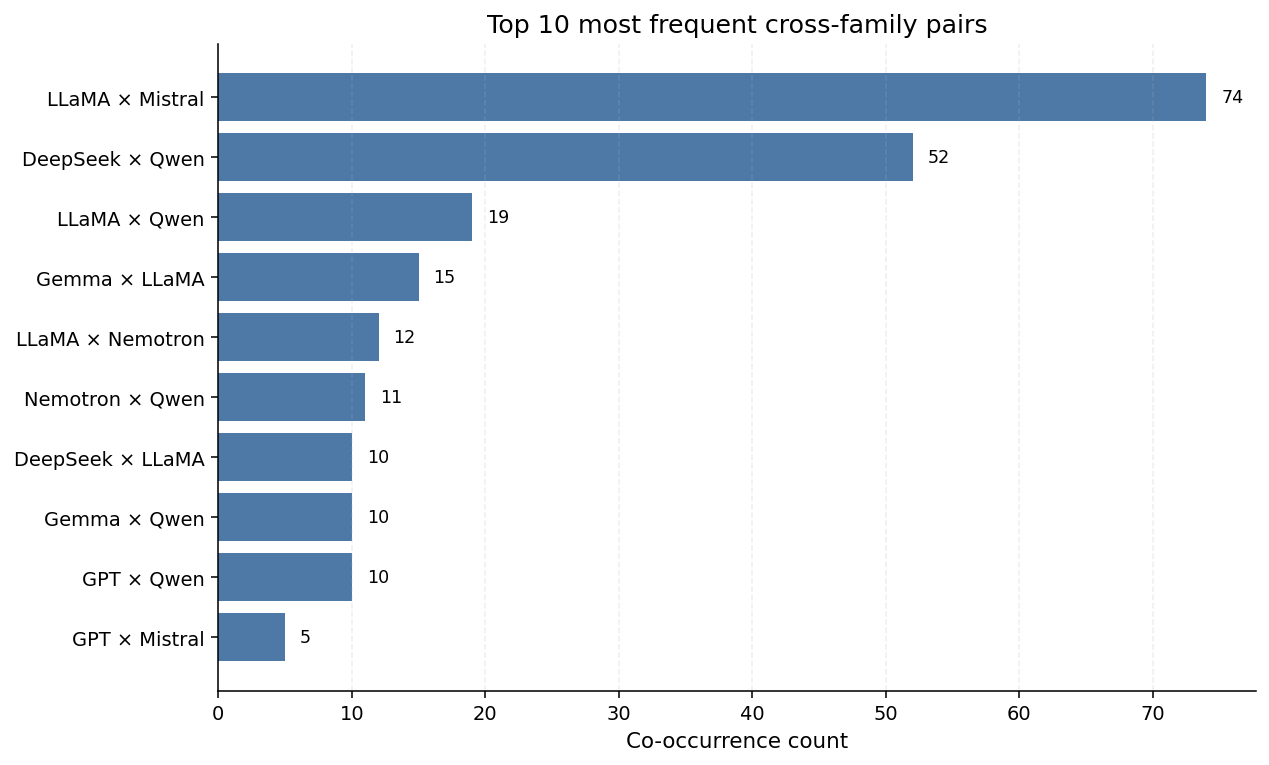

Saved RQ1 PDFs to: rq1_figures


In [2]:

# RQ1 visualizations (trimmed from visualization.py)
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

OUT = 'rq1_figures'
os.makedirs(OUT, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 140,
    'savefig.dpi': 300,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.18,
    'grid.linestyle': '--',
})

C1 = '#4E79A7'

RQ1_FILE = 'rq1_indegree_breakdown.csv'
RQ1_PAIRS = 'rq1_family_pairs.csv'


def save_pdf(name: str):
    plt.tight_layout()
    plt.savefig(os.path.join(OUT, name), bbox_inches='tight')
    plt.show()
    plt.close()

def rq1_top_cross_family_pairs():
    df = pd.read_csv(RQ1_PAIRS).copy()
    df['pair'] = df['family_a'].astype(str) + ' × ' + df['family_b'].astype(str)
    df = df.sort_values('co_occurrence_count', ascending=True).tail(10)

    fig, ax = plt.subplots(figsize=(9.2, 5.6))
    bars = ax.barh(df['pair'], df['co_occurrence_count'], color=C1)
    ax.set_title('Top 10 most frequent cross-family pairs')
    ax.set_xlabel('Co-occurrence count')
    ax.set_ylabel('')
    ax.xaxis.grid(True, alpha=0.2)
    ax.yaxis.grid(False)

    for bar in bars:
        w = bar.get_width()
        ax.text(w + max(df['co_occurrence_count']) * 0.015,
                bar.get_y() + bar.get_height() / 2,
                f'{int(w)}',
                va='center', ha='left', fontsize=9)

    save_pdf('rq1_cross_family_pairs.pdf')

rq1_top_cross_family_pairs()
print(f'Saved RQ1 PDFs to: {OUT}')
